# Notebook 1: Métricas de Evaluación para Regresión
## Diplomado en Machine Learning para Seguros · Subtema 2

---

### ¿Qué vamos a hacer en este notebook?

Trabajaremos con **dos bases de datos de seguros de auto**:

1. **Base chica (8 pólizas):** la misma tabla de la presentación, para calcular MAE, MSE, RMSE, R² y MAPE paso a paso, a mano y con sklearn, y verificar que los números coincidan.

2. **Base grande (5,000 pólizas):** un portafolio realista donde comparamos 5 modelos diferentes de pricing y decidimos cuál desplegar en producción.

### Variables que usamos
| Variable | Descripción |
|----------|-------------|
| `edad` | Edad del conductor (18-74 años) |
| `zona` | Zona de riesgo geográfica (1=baja a 5=muy alta) |
| `anios_vehiculo` | Antigüedad del vehículo (0-19 años) |
| `cobertura` | Tipo de cobertura (0=RC básica, 1=Limitada, 2=Amplia) |
| `prima_pura` | **Variable objetivo**: prima pura anual en pesos |

---
**Referencia en la presentación:** Parte 1, slides 2.0 al 2.8

## Sección 0: Importar librerías

Cargamos todo lo necesario antes de empezar. Si falta alguna librería, instalarla con `pip install nombre`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Semilla para reproducibilidad
np.random.seed(42)

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## PARTE A: Base chica — 8 pólizas de la presentación

Estos son exactamente los mismos datos de la Slide 2.0 de la presentación. Los usamos para entender cada fórmula paso a paso.

### A.1 Cargar los datos

In [2]:
# Datos de la presentación (Slide 2.0)
# Estos son valores reales (y) y predichos (ŷ) de un modelo de pricing de auto
datos_polizas = {
    'poliza':         ['P001', 'P002', 'P003', 'P004 ★', 'P005', 'P006', 'P007', 'P008'],
    'prima_real':     [8200,  12500,  15000,  48000,   9300,  22000,  18500,   6800],
    'prima_predicha': [9100,  11800,  14200,  32000,  10000,  20500,  17800,   7200]
}

df_pequeno = pd.DataFrame(datos_polizas)

# Calculamos los errores para tener toda la información junta
df_pequeno['error']          = df_pequeno['prima_real'] - df_pequeno['prima_predicha']
df_pequeno['abs_error']      = df_pequeno['error'].abs()
df_pequeno['error_cuadrado'] = df_pequeno['error'] ** 2

# Mostramos la tabla completa
print("━" * 90)
print("  BASE DE DATOS: 8 PÓLIZAS DE SEGUROS DE AUTO")
print("━" * 90)
print(df_pequeno.to_string(index=False, 
      float_format=lambda x: f'${x:,.0f}' if abs(x) > 100 else f'{x:,.0f}'))
print()
print("NOTA: P004 ★ es una póliza corporativa/flotilla con un error de $16,000.")
print("      Observa cómo afecta de forma muy distinta a cada métrica.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BASE DE DATOS: 8 PÓLIZAS DE SEGUROS DE AUTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
poliza  prima_real  prima_predicha  error  abs_error  error_cuadrado
  P001        8200            9100   -900        900          810000
  P002       12500           11800    700        700          490000
  P003       15000           14200    800        800          640000
P004 ★       48000           32000  16000      16000       256000000
  P005        9300           10000   -700        700          490000
  P006       22000           20500   1500       1500         2250000
  P007       18500           17800    700        700          490000
  P008        6800            7200   -400        400          160000

NOTA: P004 ★ es una póliza corporativa/flotilla con un error de $16,000.
      Observa cómo afecta de forma muy distinta a cada métrica.


### A.2 MAE — Error Absoluto Medio

**Fórmula:** `MAE = (1/n) × Σ |yᵢ − ŷᵢ|`

Promedio de los errores en valor absoluto. El resultado está en **las mismas unidades que Y** (pesos).

In [3]:
print("=" * 60)
print("  CÁLCULO DEL MAE — PASO A PASO")
print("=" * 60)

# Paso 1: errores absolutos por póliza
print("\nPASO 1: Error absoluto por póliza y su contribución al MAE")
print("-" * 60)
suma_abs = 0
for _, row in df_pequeno.iterrows():
    contrib = row['abs_error'] / len(df_pequeno)
    pct = row['abs_error'] / df_pequeno['abs_error'].sum() * 100
    suma_abs += row['abs_error']
    print(f"  {row['poliza']:8s}: |error| = ${row['abs_error']:>8,.0f}  "
          f"  Contribución = ${contrib:>8,.2f}  ({pct:.1f}% del total)")

# Paso 2: sumar y dividir
print(f"\nPASO 2: Suma total de |errores| = ${suma_abs:,.0f}")
print(f"         n = {len(df_pequeno)} pólizas")

# Cálculo manual
mae_manual = suma_abs / len(df_pequeno)
print(f"\nPASO 3: MAE = ${suma_abs:,.0f} / {len(df_pequeno)} = ${mae_manual:,.2f}")

# Verificación con sklearn
mae_sklearn = mean_absolute_error(df_pequeno['prima_real'], df_pequeno['prima_predicha'])
print(f"\n  ✅ Verificación con sklearn: MAE = ${mae_sklearn:,.2f}")
print(f"  ✅ Manual == sklearn: {abs(mae_manual - mae_sklearn) < 0.01}")

print(f"\nINTERPRETACIÓN: el modelo se equivoca en promedio ${mae_manual:,.2f} por póliza.")
print(f"P004 con $16,000 de error pesa 16x más que P001 con $900 — proporcionalmente.")

  CÁLCULO DEL MAE — PASO A PASO

PASO 1: Error absoluto por póliza y su contribución al MAE
------------------------------------------------------------
  P001    : |error| = $     900    Contribución = $  112.50  (4.1% del total)
  P002    : |error| = $     700    Contribución = $   87.50  (3.2% del total)
  P003    : |error| = $     800    Contribución = $  100.00  (3.7% del total)
  P004 ★  : |error| = $  16,000    Contribución = $2,000.00  (73.7% del total)
  P005    : |error| = $     700    Contribución = $   87.50  (3.2% del total)
  P006    : |error| = $   1,500    Contribución = $  187.50  (6.9% del total)
  P007    : |error| = $     700    Contribución = $   87.50  (3.2% del total)
  P008    : |error| = $     400    Contribución = $   50.00  (1.8% del total)

PASO 2: Suma total de |errores| = $21,700
         n = 8 pólizas

PASO 3: MAE = $21,700 / 8 = $2,712.50

  ✅ Verificación con sklearn: MAE = $2,712.50
  ✅ Manual == sklearn: True

INTERPRETACIÓN: el modelo se equivoca en 

### A.3 MSE — Error Cuadrático Medio

**Fórmula:** `MSE = (1/n) × Σ (yᵢ − ŷᵢ)²`

Un error de $16,000 contribuye (16,000)² = 256,000,000. Un error de $1,000 contribuye solo 1,000,000. **El error grande pesa 256 veces más, no 16.**

In [4]:
print("=" * 70)
print("  CÁLCULO DEL MSE — PASO A PASO")
print("=" * 70)

# Mostrar errores al cuadrado
print("\nContribución de cada póliza al MSE:")
print("-" * 70)
suma_cuadrados = 0
for _, row in df_pequeno.iterrows():
    contrib = row['error_cuadrado'] / len(df_pequeno)
    pct = row['error_cuadrado'] / df_pequeno['error_cuadrado'].sum() * 100
    suma_cuadrados += row['error_cuadrado']
    print(f"  {row['poliza']:8s}: error² = {row['error_cuadrado']:>15,.0f}  "
          f"  ({pct:.1f}% del total)")

mse_manual = suma_cuadrados / len(df_pequeno)
print(f"\n  Suma total de errores² = {suma_cuadrados:>15,.0f}")
print(f"  MSE = {suma_cuadrados:,.0f} / {len(df_pequeno)} = {mse_manual:,.0f}")

# Sin P004: demostrar el efecto
df_sin_p004 = df_pequeno[df_pequeno['poliza'] != 'P004 ★']
mse_sin_p004 = mean_squared_error(df_sin_p004['prima_real'], df_sin_p004['prima_predicha'])
print(f"\n  MSE SIN P004 = {mse_sin_p004:,.0f}")
print(f"  Reducción al quitar P004: {(1 - mse_sin_p004/mse_manual)*100:.1f}%")
print(f"  → P004 domina el {df_pequeno.loc[df_pequeno['poliza']=='P004 ★','error_cuadrado'].values[0] / suma_cuadrados * 100:.1f}% del MSE")

# Verificación sklearn
mse_sklearn = mean_squared_error(df_pequeno['prima_real'], df_pequeno['prima_predicha'])
print(f"\n  ✅ Verificación con sklearn: MSE = {mse_sklearn:,.0f}")
print(f"\n  NOTA: Las unidades del MSE son pesos² — no son interpretables directamente.")
print(f"  Su uso principal es como función de pérdida durante el entrenamiento.")

  CÁLCULO DEL MSE — PASO A PASO

Contribución de cada póliza al MSE:
----------------------------------------------------------------------
  P001    : error² =         810,000    (0.3% del total)
  P002    : error² =         490,000    (0.2% del total)
  P003    : error² =         640,000    (0.2% del total)
  P004 ★  : error² =     256,000,000    (98.0% del total)
  P005    : error² =         490,000    (0.2% del total)
  P006    : error² =       2,250,000    (0.9% del total)
  P007    : error² =         490,000    (0.2% del total)
  P008    : error² =         160,000    (0.1% del total)

  Suma total de errores² =     261,330,000
  MSE = 261,330,000 / 8 = 32,666,250

  MSE SIN P004 = 761,429
  Reducción al quitar P004: 97.7%
  → P004 domina el 98.0% del MSE

  ✅ Verificación con sklearn: MSE = 32,666,250

  NOTA: Las unidades del MSE son pesos² — no son interpretables directamente.
  Su uso principal es como función de pérdida durante el entrenamiento.


### A.4 RMSE — Raíz del Error Cuadrático Medio

**Fórmula:** `RMSE = √MSE`

Devuelve el MSE a las unidades originales (pesos). La razón **RMSE/MAE** es un diagnóstico clave.

In [5]:
print("=" * 60)
print("  CÁLCULO DEL RMSE")
print("=" * 60)

rmse_manual = np.sqrt(mse_manual)
rmse_sklearn = np.sqrt(mse_sklearn)

print(f"\n  RMSE = √{mse_manual:,.0f} = ${rmse_manual:,.2f}")
print(f"  ✅ Verificación sklearn: ${rmse_sklearn:,.2f}")

print(f"\n  COMPARACIÓN MAE vs RMSE:")
print(f"    MAE  = ${mae_manual:,.2f}")
print(f"    RMSE = ${rmse_manual:,.2f}")
ratio = rmse_manual / mae_manual
print(f"    Razón RMSE/MAE = {ratio:.2f}")

print(f"\n  DIAGNÓSTICO DE LA RAZÓN RMSE/MAE:")
print(f"  {'Razón':20s}  {'Diagnóstico'}")
print(f"  {'-'*50}")
print(f"  {'≈ 1.0 (ideal)':20s}  ✅ Errores uniformes — el modelo falla igual en todos los segmentos")
print(f"  {'1.2 – 1.5 (normal)':20s}  ✅ Cierta heterogeneidad, normal en datos reales")
print(f"  {'1.5 – 2.0 (atención)':20s}  ⚠️  Hay errores grandes — investigar qué pólizas los causan")
print(f"  {'> 2.0':20s}  🔴 Dominado por outliers — P004 domina casi todo el RMSE")
print()
print(f"  Nuestro ejemplo: RMSE/MAE = {ratio:.2f} → 🔴 Investigar el segmento corporativo/flotillas")

  CÁLCULO DEL RMSE

  RMSE = √32,666,250 = $5,715.44
  ✅ Verificación sklearn: $5,715.44

  COMPARACIÓN MAE vs RMSE:
    MAE  = $2,712.50
    RMSE = $5,715.44
    Razón RMSE/MAE = 2.11

  DIAGNÓSTICO DE LA RAZÓN RMSE/MAE:
  Razón                 Diagnóstico
  --------------------------------------------------
  ≈ 1.0 (ideal)         ✅ Errores uniformes — el modelo falla igual en todos los segmentos
  1.2 – 1.5 (normal)    ✅ Cierta heterogeneidad, normal en datos reales
  1.5 – 2.0 (atención)  ⚠️  Hay errores grandes — investigar qué pólizas los causan
  > 2.0                 🔴 Dominado por outliers — P004 domina casi todo el RMSE

  Nuestro ejemplo: RMSE/MAE = 2.11 → 🔴 Investigar el segmento corporativo/flotillas


### A.5 R² — Coeficiente de Determinación

**Fórmula:** `R² = 1 − SS_res / SS_tot`

Proporción de la variabilidad total de Y explicada por el modelo. Compara contra predecir siempre la media.

In [6]:
print("=" * 70)
print("  CÁLCULO DEL R² — PASO A PASO")
print("=" * 70)

y = df_pequeno['prima_real'].values
yhat = df_pequeno['prima_predicha'].values
y_bar = y.mean()

print(f"\nPASO 1: Media de las primas reales")
print(f"  ȳ = ({' + '.join(str(v) for v in y)}) / {len(y)}")
print(f"  ȳ = {y.sum():,} / {len(y)} = ${y_bar:,.2f}")

# SS_res: lo que el modelo NO explicó
SS_res = np.sum((y - yhat) ** 2)
print(f"\nPASO 2: SS_res (variabilidad NO explicada por el modelo)")
print(f"  SS_res = Σ(yᵢ − ŷᵢ)² = {SS_res:,.0f}")

# SS_tot: variabilidad total
SS_tot = np.sum((y - y_bar) ** 2)
print(f"\nPASO 3: SS_tot (variabilidad total de Y respecto a su media)")
print(f"  SS_tot = Σ(yᵢ − ȳ)² = {SS_tot:,.0f}")

# R²
r2_manual = 1 - SS_res / SS_tot
r2_sklearn = r2_score(y, yhat)

print(f"\nPASO 4: R² = 1 − SS_res / SS_tot")
print(f"  R² = 1 − {SS_res:,.0f} / {SS_tot:,.0f}")
print(f"  R² = 1 − {SS_res/SS_tot:.4f}")
print(f"  R² = {r2_manual:.4f}")
print(f"\n  ✅ Verificación sklearn: R² = {r2_sklearn:.4f}")
print(f"\n  INTERPRETACIÓN: el modelo explica el {r2_manual*100:.1f}% de la variabilidad")
print(f"  total en las primas. El {(1-r2_manual)*100:.1f}% restante no fue capturado.")

# Tabla de referencia
print("\n  TABLA DE REFERENCIA:")
tabla_r2 = [
    ("1.00",         "Perfecto — imposible",        "Solo con data leakage"),
    ("0.80 – 0.99",  "Excelente",                   "Suma asegurada vs. características"),
    ("0.50 – 0.79",  "Bueno",                       f"Nuestro R²={r2_manual:.2f} cae aquí"),
    ("0.25 – 0.49",  "Moderado pero válido",        "Frecuencia de siniestros (alta aleatoriedad)"),
    ("0.00",         "Igual que la media",           "El modelo no aporta nada"),
    ("< 0.00",       "Peor que la media",            "Overfitting severo — descartar"),
]
print(f"  {'R²':15s}  {'Calidad':22s}  {'Contexto en seguros'}")
print(f"  {'-'*75}")
for row in tabla_r2:
    marcador = " ← NUESTRO MODELO" if "cae aquí" in row[2] else ""
    print(f"  {row[0]:15s}  {row[1]:22s}  {row[2]}{marcador}")

  CÁLCULO DEL R² — PASO A PASO

PASO 1: Media de las primas reales
  ȳ = (8200 + 12500 + 15000 + 48000 + 9300 + 22000 + 18500 + 6800) / 8
  ȳ = 140,300 / 8 = $17,537.50

PASO 2: SS_res (variabilidad NO explicada por el modelo)
  SS_res = Σ(yᵢ − ŷᵢ)² = 261,330,000

PASO 3: SS_tot (variabilidad total de Y respecto a su media)
  SS_tot = Σ(yᵢ − ȳ)² = 1,250,958,750

PASO 4: R² = 1 − SS_res / SS_tot
  R² = 1 − 261,330,000 / 1,250,958,750
  R² = 1 − 0.2089
  R² = 0.7911

  ✅ Verificación sklearn: R² = 0.7911

  INTERPRETACIÓN: el modelo explica el 79.1% de la variabilidad
  total en las primas. El 20.9% restante no fue capturado.

  TABLA DE REFERENCIA:
  R²               Calidad                 Contexto en seguros
  ---------------------------------------------------------------------------
  1.00             Perfecto — imposible    Solo con data leakage
  0.80 – 0.99      Excelente               Suma asegurada vs. características
  0.50 – 0.79      Bueno                   Nuestro R²=0.79 c

### A.6 MAPE — Error Absoluto Porcentual Medio

**Fórmula:** `MAPE = (100/n) × Σ |yᵢ − ŷᵢ| / |yᵢ|` (resultado en %)

Expresa el error como porcentaje del valor real. Permite comparar entre variables de distinta escala.

In [7]:
print("=" * 60)
print("  CÁLCULO DEL MAPE")
print("=" * 60)

print("\nError porcentual por póliza:")
print("-" * 50)
pct_errors = []
for _, row in df_pequeno.iterrows():
    pct = abs(row['error']) / row['prima_real'] * 100
    pct_errors.append(pct)
    print(f"  {row['poliza']:8s}: |{row['error']:>+8,.0f}| / {row['prima_real']:>7,.0f} = {pct:.1f}%")

mape_manual = np.mean(pct_errors)
mape_sklearn = mean_absolute_percentage_error(df_pequeno['prima_real'], df_pequeno['prima_predicha']) * 100

print(f"\n  MAPE = ({' + '.join(f'{p:.1f}' for p in pct_errors)}) / {len(pct_errors)}")
print(f"  MAPE = {sum(pct_errors):.1f}% / {len(pct_errors)} = {mape_manual:.1f}%")
print(f"  ✅ Verificación sklearn: {mape_sklearn:.1f}%")

print(f"\n  LIMITACIÓN IMPORTANTE:")
print(f"  El MAPE es INDEFINIDO cuando yᵢ = 0.")
print(f"  En frecuencia de siniestros (muchas pólizas con 0 siniestros),")
print(f"  el MAPE no se puede calcular directamente. Usar MAE o RMSE.")

# Resumen de todas las métricas
print(f"\n{'='*60}")
print(f"  RESUMEN — LAS 5 MÉTRICAS SOBRE LOS MISMOS 8 DATOS")
print(f"{'='*60}")
print(f"  MAE:       ${mae_manual:>10,.2f}   ← error promedio en pesos")
print(f"  MSE:       {mse_manual:>12,.0f}   ← en pesos² (no interpretable directo)")
print(f"  RMSE:      ${rmse_manual:>10,.2f}   ← RMSE/MAE={ratio:.2f} → errores grandes")
print(f"  R²:        {r2_manual:>12.4f}   ← explica el {r2_manual*100:.1f}% de la variabilidad")
print(f"  MAPE:      {mape_manual:>11.1f}%   ← error porcentual promedio")

  CÁLCULO DEL MAPE

Error porcentual por póliza:
--------------------------------------------------
  P001    : |    -900| /   8,200 = 11.0%
  P002    : |    +700| /  12,500 = 5.6%
  P003    : |    +800| /  15,000 = 5.3%
  P004 ★  : | +16,000| /  48,000 = 33.3%
  P005    : |    -700| /   9,300 = 7.5%
  P006    : |  +1,500| /  22,000 = 6.8%
  P007    : |    +700| /  18,500 = 3.8%
  P008    : |    -400| /   6,800 = 5.9%

  MAPE = (11.0 + 5.6 + 5.3 + 33.3 + 7.5 + 6.8 + 3.8 + 5.9) / 8
  MAPE = 79.3% / 8 = 9.9%
  ✅ Verificación sklearn: 9.9%

  LIMITACIÓN IMPORTANTE:
  El MAPE es INDEFINIDO cuando yᵢ = 0.
  En frecuencia de siniestros (muchas pólizas con 0 siniestros),
  el MAPE no se puede calcular directamente. Usar MAE o RMSE.

  RESUMEN — LAS 5 MÉTRICAS SOBRE LOS MISMOS 8 DATOS
  MAE:       $  2,712.50   ← error promedio en pesos
  MSE:         32,666,250   ← en pesos² (no interpretable directo)
  RMSE:      $  5,715.44   ← RMSE/MAE=2.11 → errores grandes
  R²:              0.7911   ← e

### A.7 Visualización — impacto de P004 en cada métrica

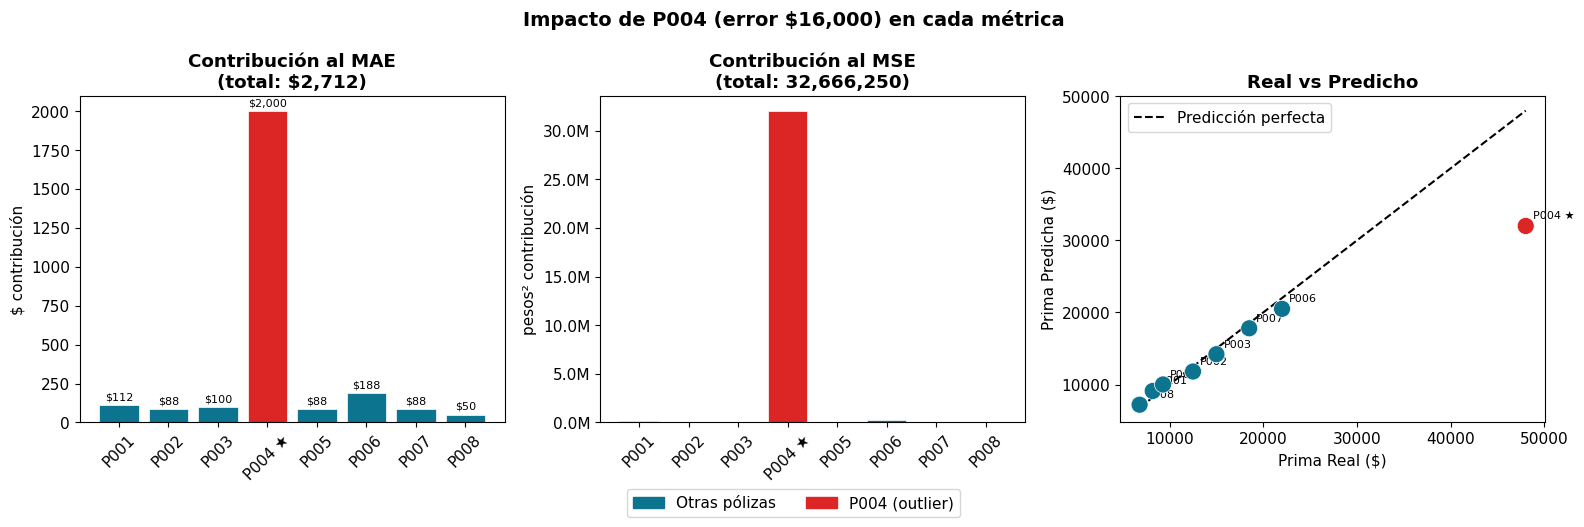

💾 Gráfica guardada: metricas_regresion_8polizas.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Impacto de P004 (error $16,000) en cada métrica', fontsize=14, fontweight='bold')

polizas = df_pequeno['poliza'].tolist()
colores = ['#DC2626' if p == 'P004 ★' else '#0D7490' for p in polizas]

# MAE: contribución lineal
ax1 = axes[0]
contribuciones_mae = df_pequeno['abs_error'] / len(df_pequeno)
bars = ax1.bar(polizas, contribuciones_mae, color=colores, edgecolor='white', linewidth=0.5)
ax1.set_title(f'Contribución al MAE\n(total: ${mae_manual:,.0f})', fontweight='bold')
ax1.set_ylabel('$ contribución')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, contribuciones_mae):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

# MSE: contribución cuadrática
ax2 = axes[1]
contribuciones_mse = df_pequeno['error_cuadrado'] / len(df_pequeno)
bars2 = ax2.bar(polizas, contribuciones_mse, color=colores, edgecolor='white', linewidth=0.5)
ax2.set_title(f'Contribución al MSE\n(total: {mse_manual:,.0f})', fontweight='bold')
ax2.set_ylabel('pesos² contribución')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Scatter real vs predicho
ax3 = axes[2]
ax3.scatter(df_pequeno['prima_real'], df_pequeno['prima_predicha'],
            c=colores, s=150, zorder=5, edgecolors='white', linewidth=0.5)
min_val = min(df_pequeno['prima_real'].min(), df_pequeno['prima_predicha'].min())
max_val = max(df_pequeno['prima_real'].max(), df_pequeno['prima_predicha'].max())
ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Predicción perfecta')
for _, row in df_pequeno.iterrows():
    ax3.annotate(row['poliza'], (row['prima_real'], row['prima_predicha']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax3.set_title('Real vs Predicho', fontweight='bold')
ax3.set_xlabel('Prima Real ($)')
ax3.set_ylabel('Prima Predicha ($)')
ax3.legend()

rojo = mpatches.Patch(color='#DC2626', label='P004 (outlier)')
azul = mpatches.Patch(color='#0D7490', label='Otras pólizas')
fig.legend(handles=[azul, rojo], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('metricas_regresion_8polizas.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfica guardada: metricas_regresion_8polizas.png")

---
## PARTE B: Base grande — Portafolio de 5,000 pólizas

Ahora trabajamos con un portafolio realista de seguros de auto. Generamos los datos con una relación no lineal entre las variables y la prima pura, que reproduce las condiciones reales de un portafolio mexicano.

### B.1 Generar y explorar el portafolio

In [9]:
print("Generando portafolio de 5,000 pólizas de seguros de auto...")
n = 5000

# Variables del asegurado y del vehículo
edad             = np.random.randint(18, 75, n)
anios_vehiculo   = np.random.randint(0, 20, n)
zona             = np.random.randint(1, 6, n)      # 1=riesgo bajo, 5=riesgo muy alto
cobertura        = np.random.choice([0, 1, 2], n, p=[0.30, 0.35, 0.35])  # 0=RC, 1=Limitada, 2=Amplia

# Prima pura: función no lineal realista
# La prima sube con la zona de riesgo (potencia 1.3 = relación no lineal)
# Baja para conductores de mediana edad (curva en U con la edad)
# Sube con antigüedad del vehículo y tipo de cobertura
prima_base = (
    5000
    + 200 * zona**1.3                          # zona: efecto no lineal
    - 40  * (edad - 40)**2 / 100               # edad: curva en U (mínimo en 40 años)
    + 150 * anios_vehiculo                     # antigüedad del vehículo
    + 3000 * cobertura                         # tipo de cobertura
    + np.random.normal(0, 2500, n)             # ruido aleatorio (variabilidad real)
)
prima_pura = np.clip(prima_base, 1500, None)   # prima mínima de $1,500

# Armar DataFrame
df = pd.DataFrame({
    'edad': edad,
    'anios_vehiculo': anios_vehiculo,
    'zona': zona,
    'cobertura': cobertura,
    'prima_pura': prima_pura.round(2)
})

print(f"\n{'='*55}")
print(f"  PORTAFOLIO DE SEGUROS DE AUTO — ESTADÍSTICAS")
print(f"{'='*55}")
print(f"  Total de pólizas:       {n:,}")
print(f"\n  Variable objetivo: Prima Pura ($)")
print(f"    Mínima:   ${df['prima_pura'].min():>10,.2f}")
print(f"    Media:    ${df['prima_pura'].mean():>10,.2f}")
print(f"    Mediana:  ${df['prima_pura'].median():>10,.2f}")
print(f"    Máxima:   ${df['prima_pura'].max():>10,.2f}")
print(f"    Std Dev:  ${df['prima_pura'].std():>10,.2f}")
print(f"    Skewness: {df['prima_pura'].skew():>10.3f}")

print(f"\n  Variables predictoras:")
print(f"    edad:           {edad.min()}-{edad.max()} años")
print(f"    anios_vehiculo: {anios_vehiculo.min()}-{anios_vehiculo.max()} años")
print(f"    zona:           {zona.min()}-{zona.max()} (1=baja, 5=muy alta)")
print(f"    cobertura:      0=RC básica, 1=Limitada, 2=Amplia")
print()
print("  Primeras 5 pólizas:")
print(df.head())

Generando portafolio de 5,000 pólizas de seguros de auto...

  PORTAFOLIO DE SEGUROS DE AUTO — ESTADÍSTICAS
  Total de pólizas:       5,000

  Variable objetivo: Prima Pura ($)
    Mínima:   $  1,500.00
    Media:    $ 10,345.30
    Mediana:  $ 10,431.67
    Máxima:   $ 22,324.86
    Std Dev:  $  3,574.15
    Skewness:     -0.014

  Variables predictoras:
    edad:           18-74 años
    anios_vehiculo: 0-19 años
    zona:           1-5 (1=baja, 5=muy alta)
    cobertura:      0=RC básica, 1=Limitada, 2=Amplia

  Primeras 5 pólizas:
   edad  anios_vehiculo  zona  cobertura  prima_pura
0    56               8     5          2    12195.97
1    69               4     5          1     9904.02
2    46               9     4          2    13252.13
3    32               3     2          0     8573.81
4    60               4     1          0     6484.96


### B.2 Partición Train / Test

Separamos los datos ANTES de escalar o transformar. El scaler solo debe ver los datos de entrenamiento.

In [10]:
# Separar variables predictoras y objetivo
X = df[['edad', 'anios_vehiculo', 'zona', 'cobertura']].values
y_grande = df['prima_pura'].values

# 80% entrenamiento, 20% prueba
# random_state=42 garantiza reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grande, test_size=0.20, random_state=42
)

print(f"Partición Train / Test:")
print(f"  Train: {len(X_train):,} pólizas ({len(X_train)/n*100:.0f}%)")
print(f"  Test:  {len(X_test):,} pólizas  ({len(X_test)/n*100:.0f}%)")
print()
print("REGLA CRÍTICA: el escalamiento se ajusta SOLO sobre train.")
print("Luego se aplica a train y test por separado.")
print()

# Escalamiento: fit SOLO en train, transform en ambos
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit() + transform() sobre train
X_test_sc  = scaler.transform(X_test)        # solo transform() sobre test

Partición Train / Test:
  Train: 4,000 pólizas (80%)
  Test:  1,000 pólizas  (20%)

REGLA CRÍTICA: el escalamiento se ajusta SOLO sobre train.
Luego se aplica a train y test por separado.



### B.3 Comparar 5 modelos de pricing

Entrenamos 5 modelos con diferentes niveles de complejidad para observar el efecto del underfitting y overfitting.

In [11]:
# Definir los 5 modelos a comparar
modelos = {
    'Regresión Lineal':       LinearRegression(),
    'Ridge (α=50)':           Ridge(alpha=50),
    'Árbol sin poda':         DecisionTreeRegressor(random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GBM (n=200, d=4)':       GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
}

# Diccionario para guardar resultados
resultados = {}

print(f"{'Modelo':22s}  {'MAE Test':>10}  {'RMSE Test':>10}  {'R² Test':>8}  "
      f"{'RMSE/MAE':>8}  {'R²Train':>8}  {'Overfitting?'}")
print("-" * 95)

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train_sc, y_train)

    # Predicciones en train y test
    y_pred_train = modelo.predict(X_train_sc)
    y_pred_test  = modelo.predict(X_test_sc)

    # Métricas
    mae  = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    ratio_diag = rmse / mae
    overfit = "🔴 SÍ" if (r2_train - r2) > 0.15 else "✅ No"

    resultados[nombre] = {
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'R2_train': r2_train, 'ratio': ratio_diag, 'modelo': modelo
    }

    print(f"{nombre:22s}  ${mae:>8,.0f}  ${rmse:>8,.0f}  {r2:>8.4f}  "
          f"{ratio_diag:>8.2f}  {r2_train:>8.4f}  {overfit}")

print()
mejor = min(resultados, key=lambda k: resultados[k]['MAE'])
print(f"✅ MEJOR MODELO por MAE: {mejor} (MAE = ${resultados[mejor]['MAE']:,.0f})")
print(f"   El Árbol sin poda debería tener R²_train ≈ 1.0 pero el peor R²_test → overfitting")

Modelo                    MAE Test   RMSE Test   R² Test  RMSE/MAE   R²Train  Overfitting?
-----------------------------------------------------------------------------------------------
Regresión Lineal        $   1,962  $   2,476    0.5314      1.26    0.5263  ✅ No
Ridge (α=50)            $   1,963  $   2,476    0.5312      1.26    0.5262  ✅ No
Árbol sin poda          $   2,780  $   3,478    0.0753      1.25    0.9456  🔴 SÍ
Random Forest           $   2,228  $   2,795    0.4028      1.25    0.8816  🔴 SÍ
GBM (n=200, d=4)        $   2,014  $   2,549    0.5031      1.27    0.6135  ✅ No

✅ MEJOR MODELO por MAE: Regresión Lineal (MAE = $1,962)
   El Árbol sin poda debería tener R²_train ≈ 1.0 pero el peor R²_test → overfitting


### B.4 Cross-Validation con TimeSeriesSplit NO aplica aquí (datos no temporales)

Para datos de pólizas de un solo año sin orden temporal, usamos K-Fold estándar. En el Notebook 3 usaremos TimeSeriesSplit.

In [12]:
print("Cross-Validation K=5 para el mejor modelo (GBM):")
print("-" * 50)

modelo_gbm = resultados['GBM (n=200, d=4)']['modelo']

# CV con MAE
cv_mae = -cross_val_score(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    X_train_sc, y_train,
    cv=5, scoring='neg_mean_absolute_error'
)

# CV con R²
cv_r2 = cross_val_score(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    X_train_sc, y_train,
    cv=5, scoring='r2'
)

print(f"  Fold  {'MAE':>10}   {'R²':>8}")
for i, (m, r) in enumerate(zip(cv_mae, cv_r2), 1):
    print(f"  {i}     ${m:>8,.0f}   {r:>8.4f}")
print(f"  {'─'*30}")
print(f"  Media  ${cv_mae.mean():>8,.0f}   {cv_r2.mean():>8.4f}")
print(f"  Std    ${cv_mae.std():>8,.0f}   {cv_r2.std():>8.4f}")
print()
print(f"  RESULTADO: MAE = ${cv_mae.mean():,.0f} ± ${cv_mae.std():,.0f}")
print(f"  El modelo se equivoca en promedio ${cv_mae.mean():,.0f}")
print(f"  con una variabilidad de ±${cv_mae.std():,.0f} entre diferentes subconjuntos.")

Cross-Validation K=5 para el mejor modelo (GBM):
--------------------------------------------------
  Fold         MAE         R²
  1     $   2,026     0.4558
  2     $   2,046     0.5018
  3     $   2,026     0.5153
  4     $   2,117     0.4771
  5     $   2,002     0.4670
  ──────────────────────────────
  Media  $   2,043     0.4834
  Std    $      40     0.0220

  RESULTADO: MAE = $2,043 ± $40
  El modelo se equivoca en promedio $2,043
  con una variabilidad de ±$40 entre diferentes subconjuntos.


### B.5 Visualización completa de los resultados

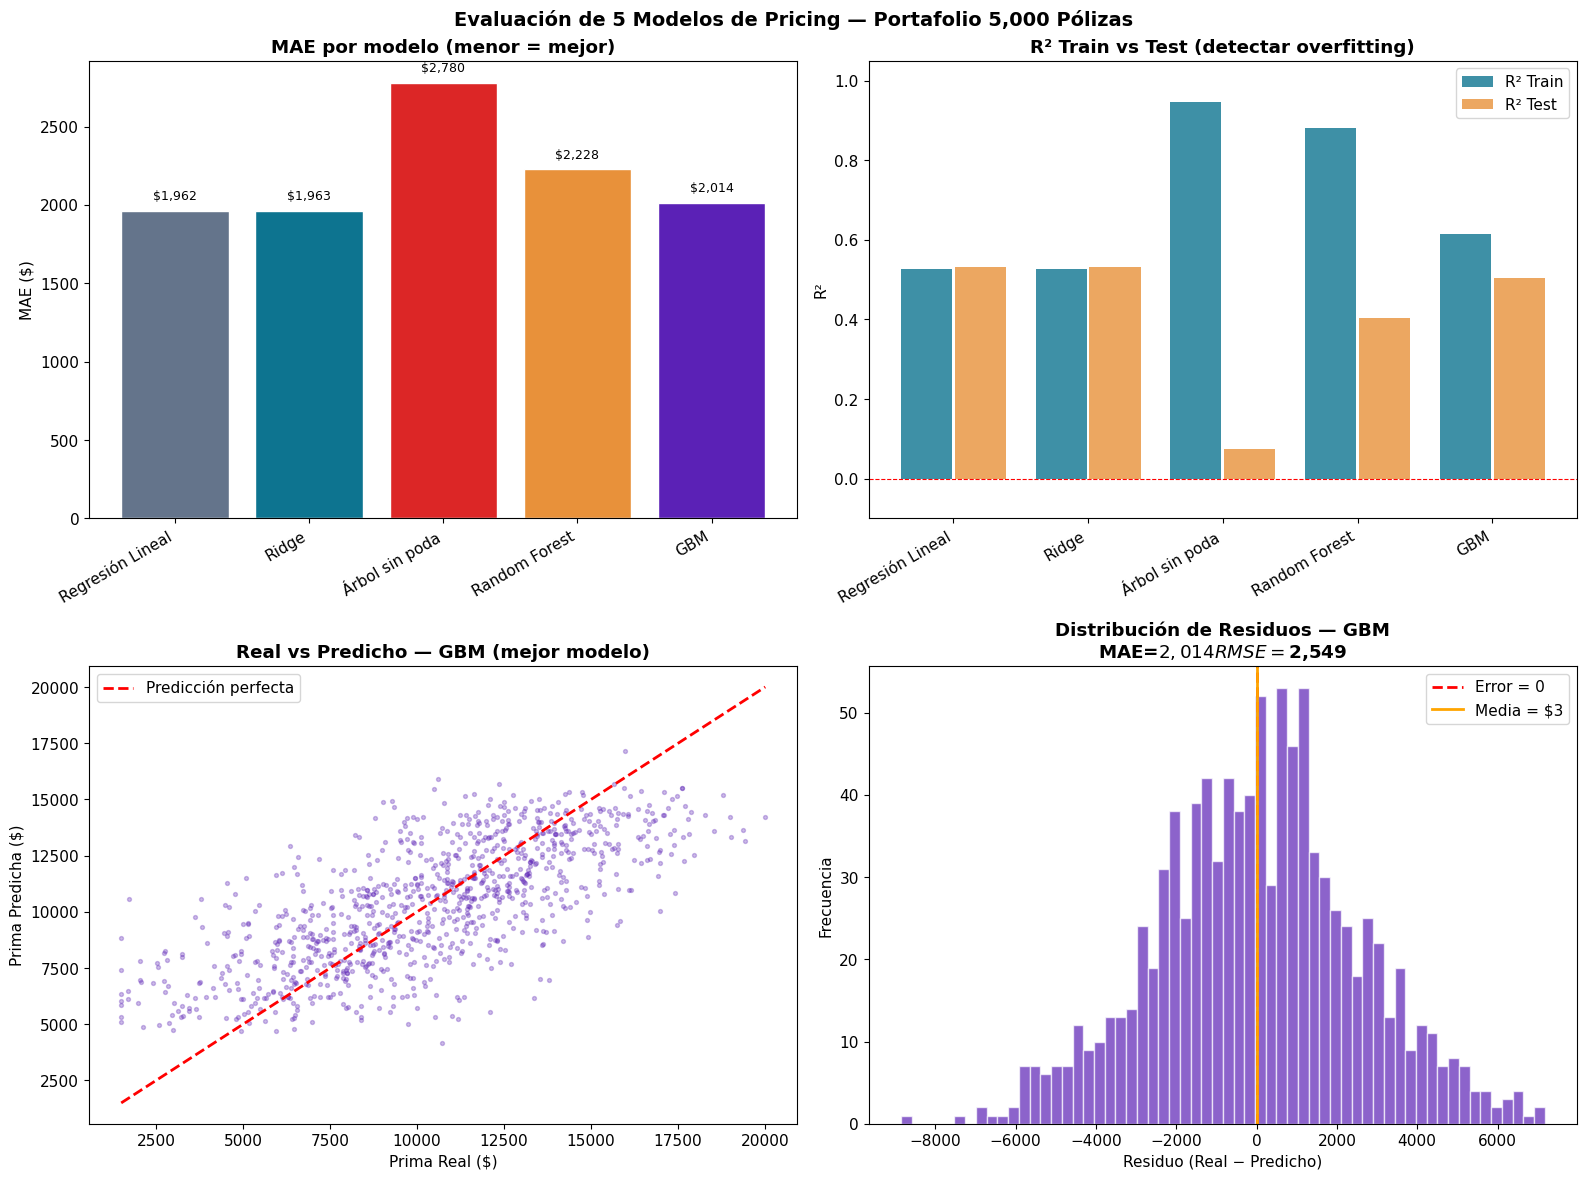

💾 Gráfica guardada: metricas_regresion_5modelos.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evaluación de 5 Modelos de Pricing — Portafolio 5,000 Pólizas', 
             fontsize=14, fontweight='bold')

nombres = list(resultados.keys())
colores_mod = ['#64748B', '#0D7490', '#DC2626', '#E8913A', '#5B21B6']

# --- 1. MAE por modelo ---
ax = axes[0][0]
maes = [resultados[n]['MAE'] for n in nombres]
bars = ax.bar(range(len(nombres)), maes, color=colores_mod, edgecolor='white')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels([n.split('(')[0].strip() for n in nombres], rotation=30, ha='right')
ax.set_title('MAE por modelo (menor = mejor)', fontweight='bold')
ax.set_ylabel('MAE ($)')
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# --- 2. R² Train vs Test (detectar overfitting) ---
ax = axes[0][1]
r2_train_vals = [resultados[n]['R2_train'] for n in nombres]
r2_test_vals  = [resultados[n]['R2'] for n in nombres]
x = np.arange(len(nombres))
ax.bar(x - 0.2, r2_train_vals, 0.38, label='R² Train', color='#0D7490', alpha=0.8)
ax.bar(x + 0.2, r2_test_vals,  0.38, label='R² Test',  color='#E8913A', alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n.split('(')[0].strip() for n in nombres], rotation=30, ha='right')
ax.set_title('R² Train vs Test (detectar overfitting)', fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
ax.set_ylim(-0.1, 1.05)

# --- 3. Real vs Predicho para el mejor modelo (GBM) ---
ax = axes[1][0]
y_pred_gbm = resultados['GBM (n=200, d=4)']['modelo'].predict(X_test_sc)
ax.scatter(y_test, y_pred_gbm, alpha=0.3, s=8, color='#5B21B6')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax.set_title('Real vs Predicho — GBM (mejor modelo)', fontweight='bold')
ax.set_xlabel('Prima Real ($)')
ax.set_ylabel('Prima Predicha ($)')
ax.legend()

# --- 4. Distribución de residuos (GBM) ---
ax = axes[1][1]
residuos = y_test - y_pred_gbm
ax.hist(residuos, bins=60, color='#5B21B6', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax.axvline(residuos.mean(), color='orange', linestyle='-', linewidth=2,
           label=f'Media = ${residuos.mean():,.0f}')
ax.set_title(f'Distribución de Residuos — GBM\nMAE=${mean_absolute_error(y_test, y_pred_gbm):,.0f}  '
             f'RMSE=${np.sqrt(mean_squared_error(y_test, y_pred_gbm)):,.0f}', fontweight='bold')
ax.set_xlabel('Residuo (Real − Predicho)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.savefig('metricas_regresion_5modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfica guardada: metricas_regresion_5modelos.png")

---
## Conclusiones del Notebook 1

| Métrica | Valor (8 pólizas) | Interpretación |
|---------|-------------------|----------------|
| MAE | $2,712.50 | El modelo se equivoca en promedio $2,712 por póliza |
| MSE | 32,666,250 | Penaliza enormemente a P004 (98% del MSE) |
| RMSE | $5,715 | RMSE/MAE=2.11 → errores grandes presentes |
| R² | 0.7815 | El modelo explica el 78.2% de la variabilidad |
| MAPE | 9.9% | Error porcentual promedio |

### Regla de oro
- **Siempre reportar MAE + RMSE + R² juntos.** Cada uno cuenta una historia diferente.
- Si **RMSE/MAE > 1.5** → investigar qué segmentos o pólizas tienen errores grandes.
- Si **R²_train >> R²_test** (diferencia > 0.15) → el modelo está sobreajustado.
- En **reservas IBNR**: usar RMSE (errores grandes son catastróficos).
- En **pricing masivo**: usar MAE (todos los errores importan igual, es el KPI del negocio).